In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Math
from scipy import signal
from scipy.fft import ifft, rfft, rfftfreq

import utils_TF

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

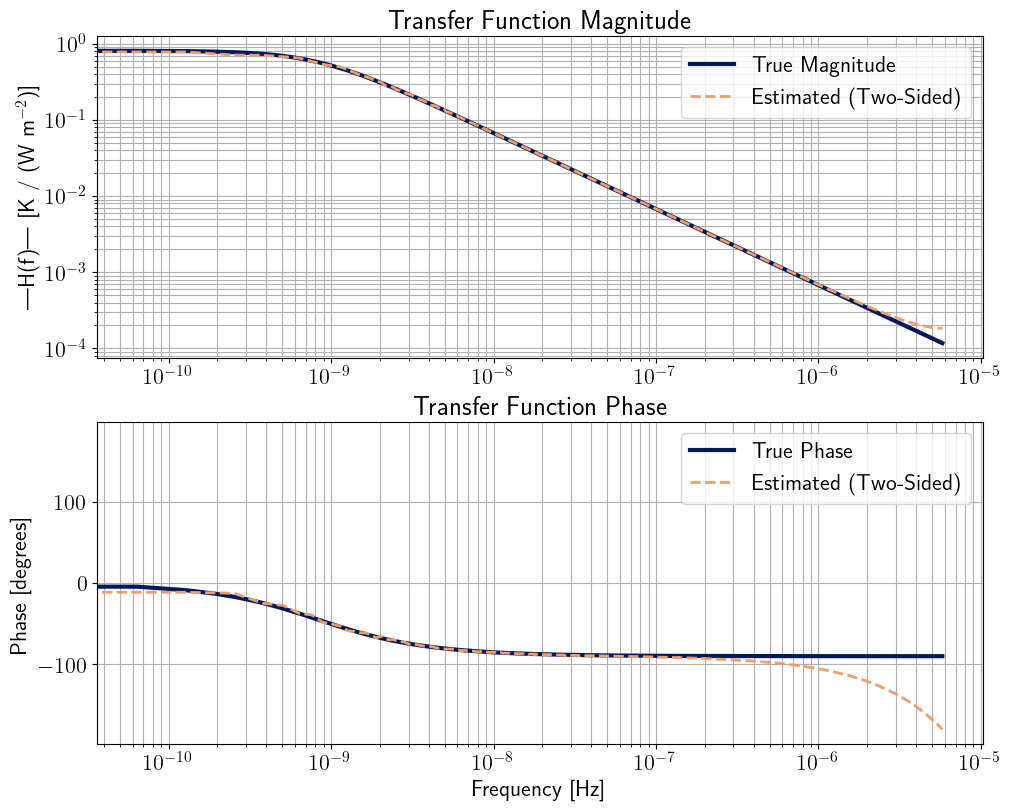

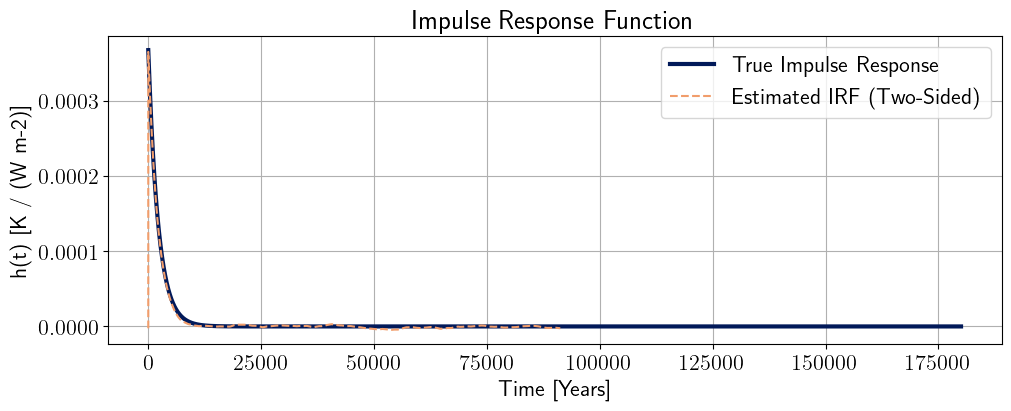

In [8]:
def integrate_box_model(C, lambda_, forcing, dt):
    """
    Integrates a one-box climate model.

    Args:
        C (float): Heat capacity (J m^-2 K^-1).
        lambda_ (float): Climate feedback parameter (W m^-2 K^-1).
        forcing (np.ndarray): Time series of radiative forcing (W m^-2).
        dt (float): Time step in seconds.

    Returns:
        np.ndarray: Time series of temperature anomaly (K).
    """
    n_steps = len(forcing)
    T = np.zeros(n_steps)
    for i in range(n_steps - 1):
        T[i+1] = T[i] + (dt / C) * (forcing[i] - lambda_ * T[i])
    return T

# --- 1. System Definition and Signal Generation ---

# Model parameters for a one-box model
C = 2.35e8  # Heat capacity of a 70m ocean mixed layer (J m^-2 K^-1)
lambda_ = 1.23 # Climate feedback parameter (W m^-2 K^-1)

# Time parameters
dt = 24 * 3600  # Daily time step in seconds
fs = 1 / dt      # Sampling frequency in Hz
years = 500
n_steps = years * 360
time = np.arange(n_steps) * dt

# Input signal (unfiltered white noise)
F_train = np.random.randn(n_steps)

F_abrupt = np.zeros(n_steps)
F_abrupt[:] = 3.7 # Standard forcing for 2xCO2

# b) Exponential Growth Forcing
F_max = 3.7
amp = F_max / np.exp(years/50)
tau_forcing_seconds = 50 * dt * 360
F_exp = amp * (np.exp(time / tau_forcing_seconds))

# Calculate the temperature response using the box model
T_train = integrate_box_model(C, lambda_, F_train, dt)

# --- 2. Calculate True System Responses for Comparison ---

# True Impulse Response Function (IRF)
# The analytical solution for the IRF of this box model is an exponential decay.
tau = C / lambda_  # e-folding timescale of the system
h_true = (dt / C) * np.exp(-time / tau)

# True Transfer Function
# We can get this by taking the FFT of the true impulse response.
# Or, analytically, H(w) = 1 / (lambda + i*w*C)
w = 2 * np.pi * np.fft.rfftfreq(n_steps, d=dt) # Angular frequency
H_true = 1 / (lambda_ + 1j * w * C)
f_true = w / (2 * np.pi)

nperseg = 365 * 250

H_est, h_est, f = utils_TF.identify_system(F_train, T_train, fs, nperseg)
utils_TF.plot_freq(H_est, f, plot_true=True, H_true=H_true, f_true=f_true)
utils_TF.plot_time(h_est, plot_true=True, h_true=h_true)

Scenario: Abrupt 2xCO2 | RMSE: 0.4389 K


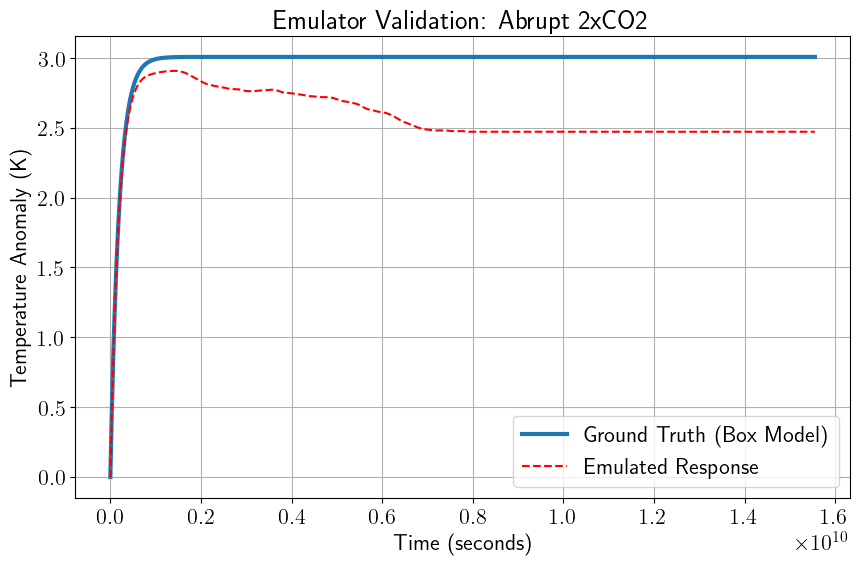

Scenario: Exponential | RMSE: 0.0281 K


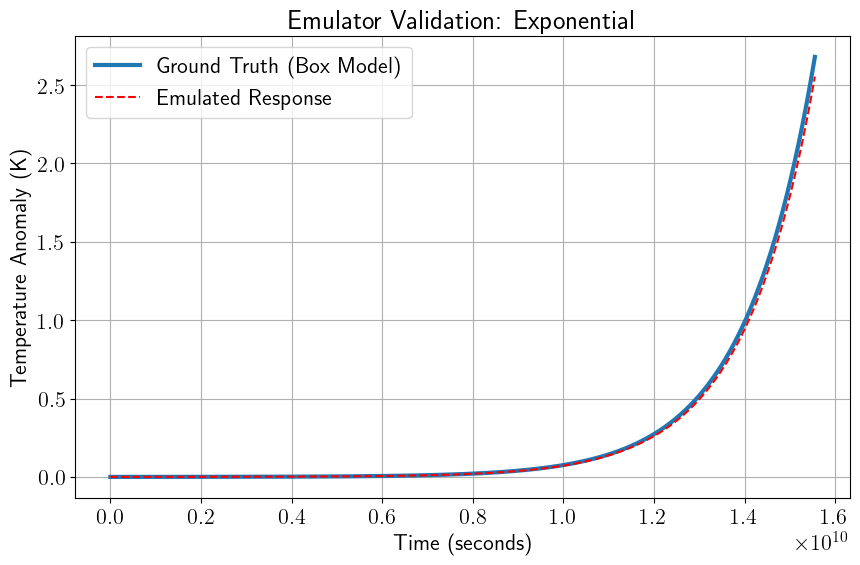

In [4]:
scenarios = {
    "Abrupt 2xCO2": F_abrupt,
    "Exponential": F_exp
}

for name, F in scenarios.items():
  # Get ground truth from the box model
  T_true = integrate_box_model(C, lambda_, F, dt)

  # Get emulated response via convolution
  T_emulated = signal.convolve(F, h_est, mode='full')[:len(F)]

  # Calculate RMSE
  rmse = np.sqrt(np.mean((T_true - T_emulated)**2))
  print(f"Scenario: {name} | RMSE: {rmse:.4f} K")

  # Plot comparison
  plt.figure(figsize=(10, 6))
  plt.plot(time, T_true, label='Ground Truth (Box Model)', lw=3)
  plt.plot(time, T_emulated, 'r--', label='Emulated Response')
  plt.title(f'Emulator Validation: {name}')
  plt.xlabel('Time (seconds)')
  plt.ylabel('Temperature Anomaly (K)')
  plt.legend()
  plt.grid(True)
  plt.show()

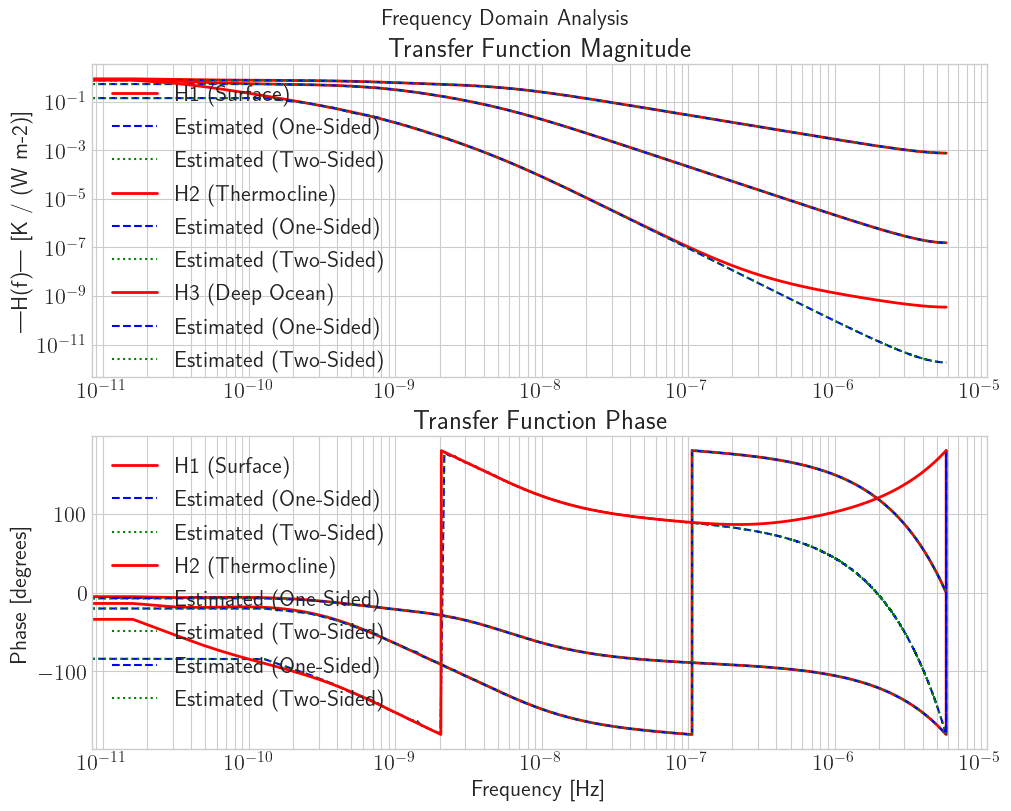

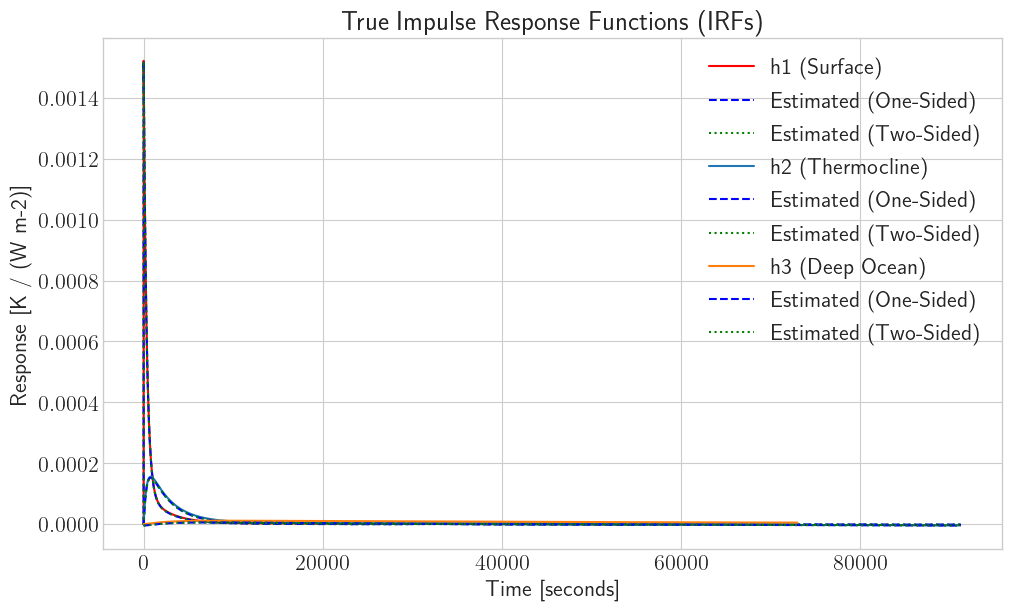

In [269]:
def integrate_3box_model(params, forcing, dt):
    """
    Integrates a three-box climate model.

    Args:
        params (dict): Dictionary of model parameters.
        forcing (np.ndarray): Time series of radiative forcing (W m^-2).
        dt (float): Time step in seconds.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: Time series of temperature
        anomalies for the surface (T1), thermocline (T2), and deep ocean (T3).
    """
    # Unpack parameters
    C1, C2, C3 = params['C1'], params['C2'], params['C3']
    lambda_ = params['lambda_']
    gamma1, gamma2 = params['gamma1'], params['gamma2']

    n_steps = len(forcing)
    T1, T2, T3 = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)

    for i in range(n_steps - 1):
        # Fluxes between boxes
        F12 = gamma1 * (T1[i] - T2[i])
        F23 = gamma2 * (T2[i] - T3[i])

        # Update each box temperature
        T1[i+1] = T1[i] + (dt / C1) * (forcing[i] - lambda_ * T1[i] - F12)
        T2[i+1] = T2[i] + (dt / C2) * (F12 - F23)
        T3[i+1] = T3[i] + (dt / C3) * F23

    return T1, T2, T3

# --- 1. System Definition ---

# Model parameters for a three-box model with realistic timescales
# Based on Geoffroy et al. (2013)
s_in_year = 360 * 24 * 3600
params = {
    'C1': 7.3 * (s_in_year / 4),  # Fast: Mixed layer (~2-3 years)
    'C2': 19 * (s_in_year / 4), # Medium: Thermocline (~50-100 years)
    'C3': 140 * (s_in_year / 4),# Slow: Deep ocean (~1000+ years)
    'lambda_': 1.1,             # Climate feedback parameter (W m^-2 K^-1)
    'gamma1': 0.7,              # Surface-thermocline coupling
    'gamma2': 0.3               # Thermocline-deep ocean coupling
}

# Time parameters
dt = 24 * 3600      # Daily time step in seconds
fs = 1 / dt         # Sampling frequency in Hz
years = 2000
n_steps = years * 360
time = np.arange(n_steps) * dt

# --- 2. Calculate True System Response Functions ---

# a) True Impulse Response Functions (IRFs)
# We derive this numerically by feeding a single, scaled impulse into the model.
F_impulse = np.zeros(n_steps)
F_impulse[0] = 1.0 / dt # A discrete delta function has an integral of 1
h1_true, h2_true, h3_true = integrate_3box_model(params, F_impulse, dt)

F_max = 3.7
amp = F_max / np.exp(years/50)
tau_forcing_seconds = 50 * dt * 360
F_exp = amp * (np.exp(time / tau_forcing_seconds))

# b) True Transfer Functions
# We get these by taking the FFT of the true impulse responses.
f_true = rfftfreq(n_steps, d=dt)
H1_true = rfft(h1_true) * dt
H2_true = rfft(h2_true) * dt
H3_true = rfft(h3_true) * dt


# --- 3. Run a Sample Simulation (e.g., Abrupt 2xCO2) ---
F_abrupt = np.zeros(n_steps)
F_abrupt[:] = 3.7 # Standard forcing for 2xCO2

T1, T2, T3 = integrate_3box_model(params, F_abrupt, dt)

F_train = np.random.randn(n_steps)*2
T_train1, T_train2, T_train3 = integrate_3box_model(params, F_train, dt)

H1_est1, h1_est1, f11, H1_est2, h1_est2, f12 = identify_system(F_train, T_train1)
H2_est1, h2_est1, f21, H2_est2, h2_est2, f22 = identify_system(F_train, T_train2)
H3_est1, h3_est1, f31, H3_est2, h3_est2, f32 = identify_system(F_train, T_train3)

# --- Frequency Domain Plots ---
fig_freq, axes_freq = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)
fig_freq.suptitle("Frequency Domain Analysis", fontsize=16)

# Magnitude Plot
axes_freq[0].loglog(f_true, np.abs(H1_true), 'r-', lw=2, label='H1 (Surface)')
axes_freq[0].loglog(f11, np.abs(H1_est1), 'b--', label='Estimated (One-Sided)')
axes_freq[0].loglog(np.fft.fftshift(f12), np.fft.fftshift(np.abs(H1_est2)), 'g:', label='Estimated (Two-Sided)')

axes_freq[0].loglog(f_true, np.abs(H2_true), 'r-', lw=2, label='H2 (Thermocline)')
axes_freq[0].loglog(f21, np.abs(H2_est1), 'b--', label='Estimated (One-Sided)')
axes_freq[0].loglog(np.fft.fftshift(f22), np.fft.fftshift(np.abs(H2_est2)), 'g:', label='Estimated (Two-Sided)')

axes_freq[0].loglog(f_true, np.abs(H3_true), 'r-', lw=2, label='H3 (Deep Ocean)')
axes_freq[0].loglog(f31, np.abs(H3_est1), 'b--', label='Estimated (One-Sided)')
axes_freq[0].loglog(np.fft.fftshift(f32), np.fft.fftshift(np.abs(H3_est2)), 'g:', label='Estimated (Two-Sided)')

axes_freq[0].set_title("Transfer Function Magnitude")
axes_freq[0].set_ylabel("|H(f)| [K / (W m-2)]")
axes_freq[0].grid(True, which='both')
axes_freq[0].legend()

# Phase Plot
axes_freq[1].semilogx(f_true, np.angle(H1_true, deg=True), 'r-', lw=2, label='H1 (Surface)')
axes_freq[1].semilogx(f11, np.angle(H1_est1, deg=True), 'b--', label='Estimated (One-Sided)')
axes_freq[1].semilogx(np.fft.fftshift(f12), np.fft.fftshift(np.angle(H1_est2, deg=True)), 'g:', label='Estimated (Two-Sided)')

axes_freq[1].semilogx(f_true, np.angle(H2_true, deg=True), 'r-', lw=2, label='H2 (Thermocline)')
axes_freq[1].semilogx(f21, np.angle(H2_est1, deg=True), 'b--', label='Estimated (One-Sided)')
axes_freq[1].semilogx(np.fft.fftshift(f22), np.fft.fftshift(np.angle(H2_est2, deg=True)), 'g:', label='Estimated (Two-Sided)')

axes_freq[1].semilogx(f31, np.angle(H3_est1, deg=True), 'b--', label='Estimated (One-Sided)')
axes_freq[1].semilogx(np.fft.fftshift(f32), np.fft.fftshift(np.angle(H3_est2, deg=True)), 'g:', label='Estimated (Two-Sided)')

axes_freq[1].set_title("Transfer Function Phase")
axes_freq[1].set_xlabel("Frequency [Hz]")
axes_freq[1].set_ylabel("Phase [degrees]")
axes_freq[1].grid(True, which='both')
axes_freq[1].legend()

axes_freq[1].semilogx(f_true, np.angle(H3_true, deg=True), 'r-', lw=2, label='H3 (Deep Ocean)')
# Plot the true impulse response functions
fig_irf, ax_irf = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)

ax_irf.plot(h1_true[:plot_len] * dt, 'r-', label='h1 (Surface)')
ax_irf.plot(h1_est1, 'b--', label='Estimated (One-Sided)')
ax_irf.plot(h1_est2, 'g:', label='Estimated (Two-Sided)')

ax_irf.plot(h2_true[:plot_len] * dt, label='h2 (Thermocline)')
ax_irf.plot(h2_est1, 'b--', label='Estimated (One-Sided)')
ax_irf.plot(h2_est2, 'g:', label='Estimated (Two-Sided)')

ax_irf.plot(h3_true[:plot_len] * dt, label='h3 (Deep Ocean)')
ax_irf.plot(h3_est1, 'b--', label='Estimated (One-Sided)')
ax_irf.plot(h3_est2, 'g:', label='Estimated (Two-Sided)')

ax_irf.set_title('True Impulse Response Functions (IRFs)')
ax_irf.set_xlabel('Time [seconds]')
ax_irf.set_ylabel('Response [K / (W m-2)]')
ax_irf.grid(True)
ax_irf.legend()

Scenario: Abrupt 2xCO2 | RMSE: 0.3610 K
Scenario: Abrupt 2xCO2 | RMSE: 1.1467 K
Scenario: Abrupt 2xCO2 | RMSE: 2.8469 K


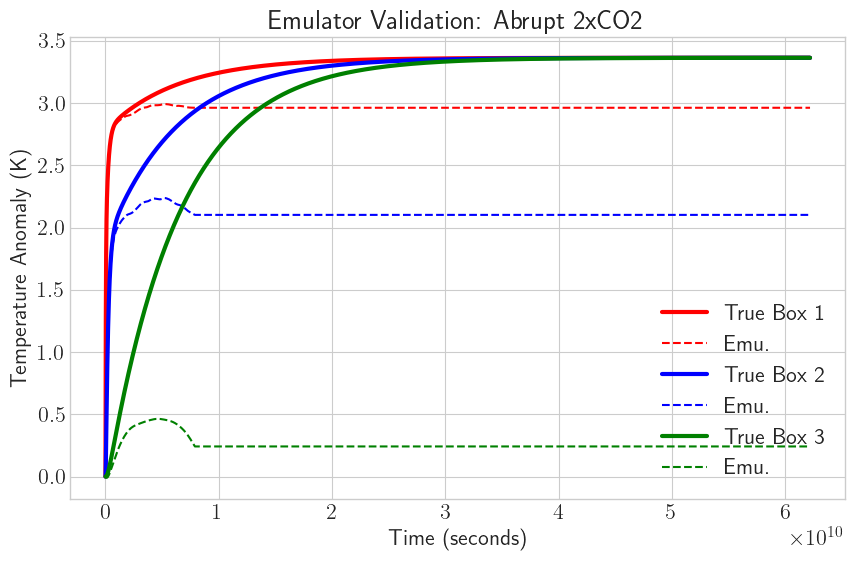

Scenario: Exponential | RMSE: 0.0034 K
Scenario: Exponential | RMSE: 0.0150 K
Scenario: Exponential | RMSE: 0.0404 K


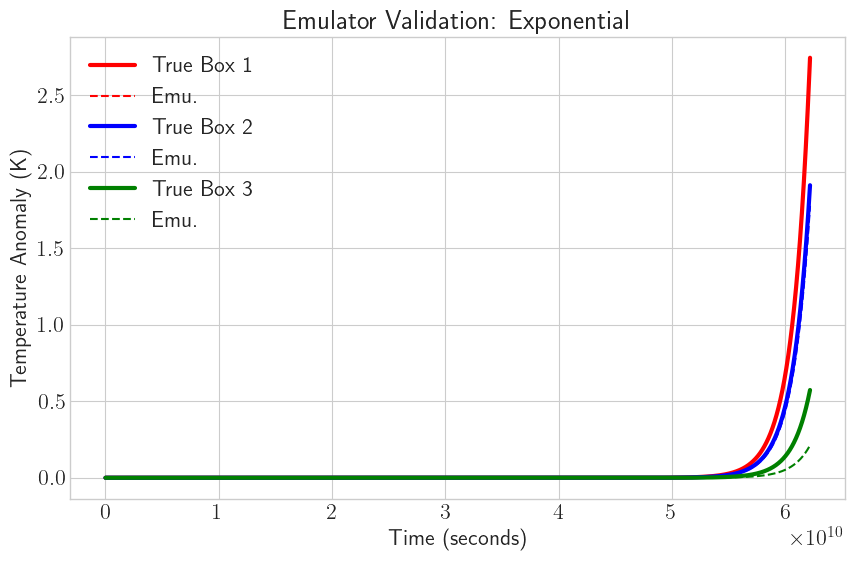

In [267]:
scenarios = {
    "Abrupt 2xCO2": F_abrupt,
    "Exponential": F_exp
}

for name, F in scenarios.items():
  # Get ground truth from the box model
  T_true1, T_true2, T_true3 = integrate_3box_model(params, F, dt)

  # Get emulated response via convolution
  T_emu1 = signal.convolve(F, h1_est1, mode='full')[:len(F)]
  T_emu2 = signal.convolve(F, h2_est1, mode='full')[:len(F)]
  T_emu3 = signal.convolve(F, h3_est1, mode='full')[:len(F)]

  # Calculate RMSE
  rmse1 = np.sqrt(np.mean((T_true1 - T_emu1)**2))
  print(f"Scenario: {name} | RMSE: {rmse1:.4f} K")
  rmse2 = np.sqrt(np.mean((T_true2 - T_emu2)**2))
  print(f"Scenario: {name} | RMSE: {rmse2:.4f} K")
  rmse3 = np.sqrt(np.mean((T_true3 - T_emu3)**2))
  print(f"Scenario: {name} | RMSE: {rmse3:.4f} K")

  # Plot comparison
  plt.figure(figsize=(10, 6))
  plt.plot(time, T_true1, 'r-', label='True Box 1', lw=3)
  plt.plot(time, T_emu1, 'r--', label='Emu.')
  plt.plot(time, T_true2, 'b-', label='True Box 2', lw=3)
  plt.plot(time, T_emu2, 'b--', label='Emu.')
  plt.plot(time, T_true3, 'g-', label='True Box 3', lw=3)
  plt.plot(time, T_emu3, 'g--', label='Emu.')
  plt.title(f'Emulator Validation: {name}')
  plt.xlabel('Time (seconds)')
  plt.ylabel('Temperature Anomaly (K)')
  plt.legend()
  plt.grid(True)
  plt.show()

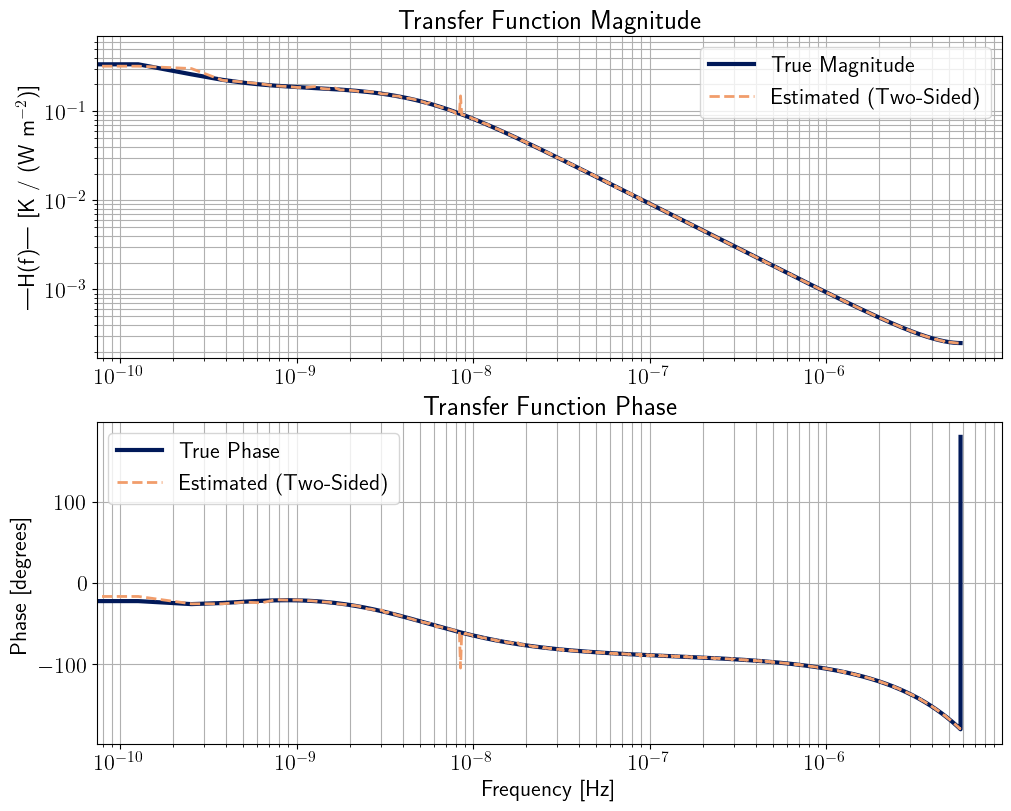

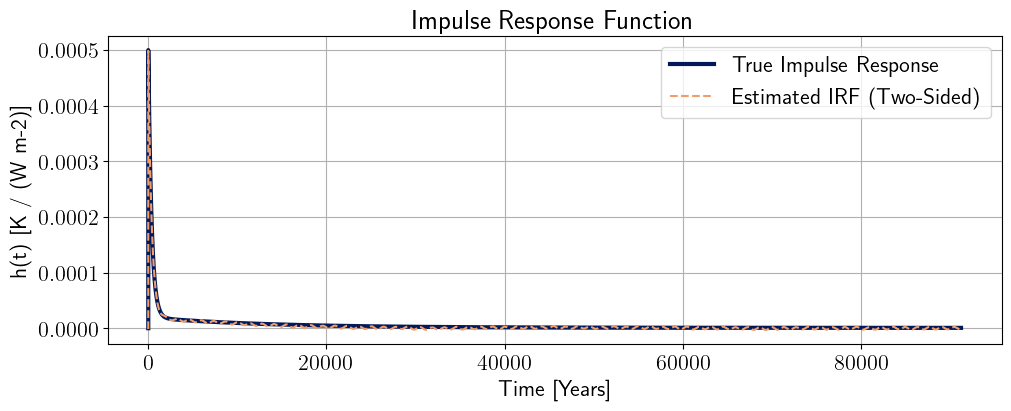

In [17]:
def integrate_3box_model(params, forcing, dt):
    """
    Integrates a three-box climate model.

    Args:
        params (dict): Dictionary of model parameters.
        forcing (np.ndarray): Time series of radiative forcing (W m^-2).
        dt (float): Time step in seconds.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: Time series of temperature
        anomalies for the surface (T1), thermocline (T2), and deep ocean (T3).
    """
    # Unpack parameters
    C1, C2, C3 = params['C1'], params['C2'], params['C3']
    lambda_ = params['lambda_']
    gamma1, gamma2 = params['gamma1'], params['gamma2']

    n_steps = len(forcing)
    T1, T2, T3 = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)

    for i in range(n_steps - 1):
        # Fluxes between boxes
        F12 = gamma1 * (T1[i] - T2[i])
        F23 = gamma2 * (T2[i] - T3[i])

        # Update each box temperature
        T1[i+1] = T1[i] + (dt / C1) * (forcing[i] - lambda_ * T1[i] - F12)
        T2[i+1] = T2[i] + (dt / C2) * (F12 - F23)
        T3[i+1] = T3[i] + (dt / C3) * F23

    return T1, T2, T3

# --- 1. System Definition ---
s_in_year = 365.25 * 24 * 3600
params = {
    'C1': 7.3 * (s_in_year / 4), 'C2': 104 * (s_in_year / 4), 'C3': 1400 * (s_in_year / 4),
    'lambda_': 1.1, 'gamma1': 0.7, 'gamma2': 0.3
}
dt = 24 * 3600
fs = 1 / dt
years = 250
n_steps = years * 365
time = np.arange(n_steps) * dt

# --- 2. Calculate True System Response Functions ---
F_impulse = np.zeros(n_steps)
F_impulse[0] = 1.0 / dt
h1_true, h2_true, h3_true = integrate_3box_model(params, F_impulse, dt)

# Global average is an even weighted sum
h_global_true = (h1_true + h2_true + h3_true) / 3.0

f_true = rfftfreq(n_steps, d=dt)
H_global_true = rfft(h_global_true) * dt

# --- 3. Generate Training Data and Estimate System ---
# Use a high-amplitude forcing signal for better SNR in deep boxes
F_train = np.random.randn(n_steps) * 100
T1_train, T2_train, T3_train = integrate_3box_model(params, F_train, dt)

# Global average temperature is the target output for our system ID
T_global_train = (T1_train + T2_train + T3_train) / 3.0

# Identify the globally averaged system
nperseg = 365 * 250
H_est, h_est, f = utils_TF.identify_system(F_train, T_global_train, fs, nperseg)

utils_TF.plot_freq(H_est, f, plot_true=True, H_true=H_global_true, f_true=f_true)
utils_TF.plot_time(h_est, plot_true=True, h_true=h_global_true*dt)

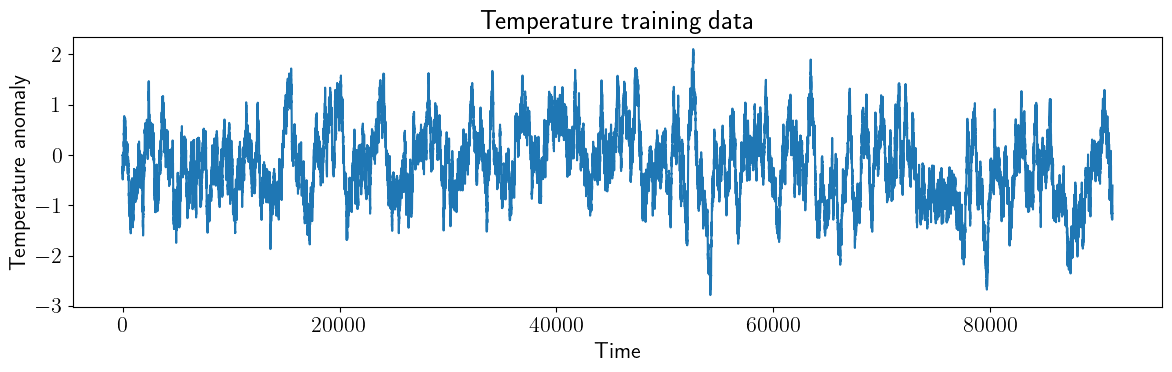

In [20]:
plt.plot(T_global_train)
plt.title('Temperature training data')
plt.xlabel('Time')
plt.ylabel('Temperature anomaly')
plt.tight_layout()